In [1]:
from __future__ import annotations
from copy import deepcopy
from pathlib import Path
from typing import Iterable, Dict, Optional, Tuple, Union

import numpy as np
import pandas as pd

import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d


# Import your core model utilities
import sys
sys.path.append("..")
from bioprocess_utils import (
    load_model_inputs, run_model, minimal_parameters, minimal_initials, generate_pputida_dataset, load_synthetic_dataset, plot_spaghetti, plot_mean_std, plot_boxplot
)

In [2]:
t_eval = [0.0, 50.0, 100.0, 250.0, 400.0, 600.0]
# Minimal: make 5 experiments, 80 timestamps, Biomass & Sub only
df, meta = generate_pputida_dataset(
    inputs="../inputs/inputs.json",     # your uploaded inputs
    variables=("Biomass","Sub"),
    n_experiments=5,
    n_timepoints=80,
    noise_cv=0.05,
    aberrant_prob=0.01,
    missing_prob=0.0,
    save_dir=".",
    basename="pputida_fedbatch_v1",
    seed=123,
    t_eval = t_eval
)

print(df.head())
print(meta["units"])     # {'Biomass': 'g', 'Sub': 'mol'}


   experiment   time   Biomass           Sub
0           0    0.0  0.045179  1.372784e-01
1           0   50.0  0.059332  1.226502e-01
2           0  100.0  0.087655  1.022300e-01
3           0  250.0  0.182922  9.361409e-06
4           0  400.0  0.182878  4.905391e-12
{'Biomass': 'g', 'Sub': 'mol'}


In [3]:
# gas generation
df, meta = generate_pputida_dataset(
    inputs="../inputs/inputs.json",
    variables=("Biomass","Sub","O2_l","CO2_l","CO2_g"),
    n_experiments=8, n_timepoints=120,
    noise_cv_per_var={"O2_l":0.08, "CO2_l":0.08, "CO2_g":0.08}
)

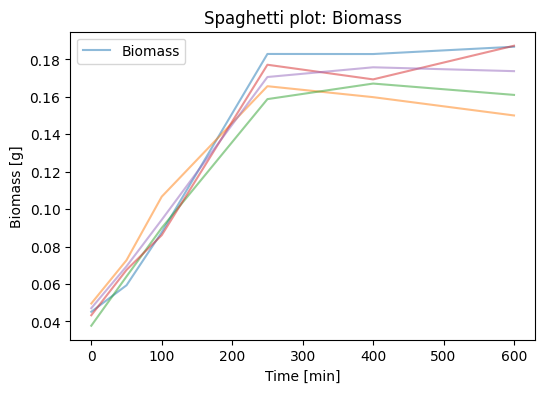

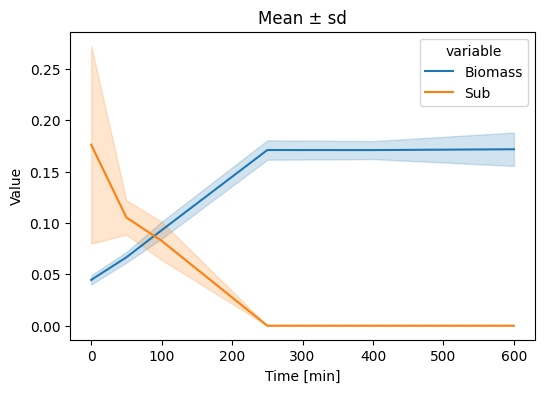

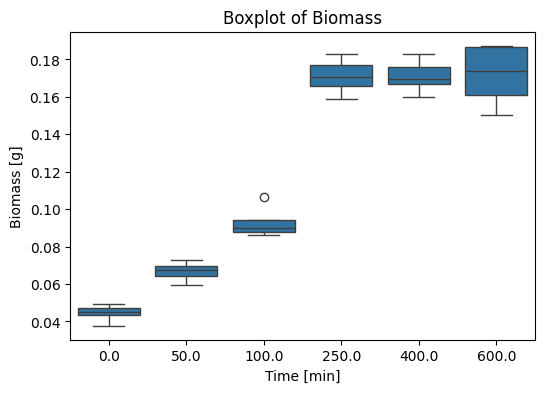

In [4]:
# Load your saved dataset
df, meta = load_synthetic_dataset("./pputida_fedbatch_v1.wide.csv")

# Spaghetti plot for Biomass
plot_spaghetti(df, meta, variables=["Biomass"])

# Mean ± std for Biomass and Substrate
plot_mean_std(df, meta, variables=["Biomass", "Sub"])
plt.show()

# Boxplot for Biomass at selected times
plot_boxplot(df, meta, variable="Biomass", time_points=t_eval)
plt.show()
